In [1]:
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
import math

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd


Ragasa UTC window: 2025-09-23 10:00 to 2025-09-24 10:00 (inclusive).
Yagi UTC window: 2024-09-05 00:00 to 2024-09-06 00:00 (inclusive).


Shared hexbin LogNorm range for color scale: vmin=1, vmax=210


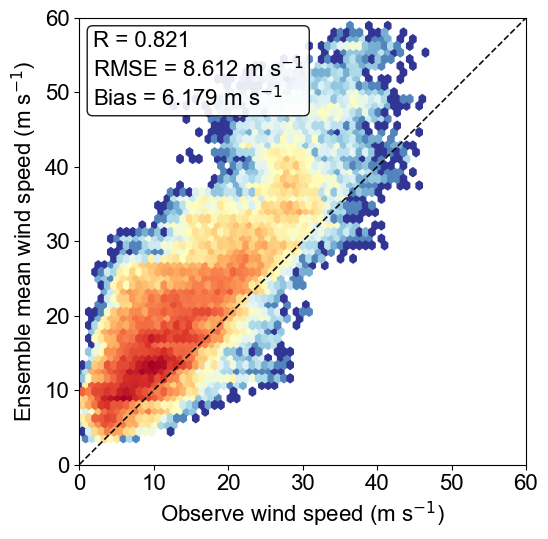

ragasa 24h mean_wspd: saved meanwspd_obs_vs_multi_ai_hexbin_ragasa_24h_20250923-10_to_20250924-10.tif with 43,092 paired station-time samples.


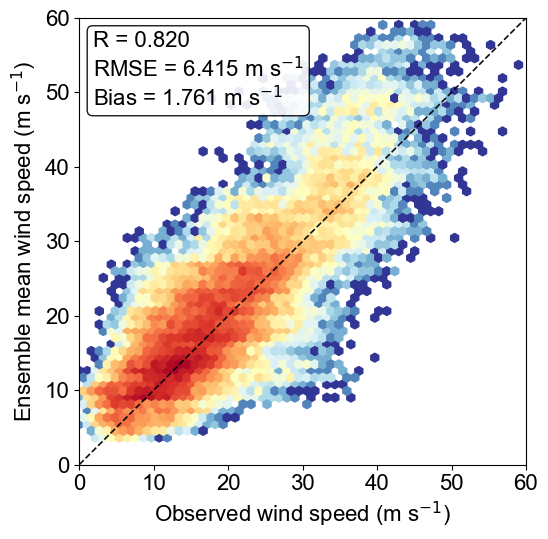

ragasa 24h max_wspd: saved maxwspd_obs_vs_multi_ai_hexbin_ragasa_24h_20250923-10_to_20250924-10.tif with 43,170 paired station-time samples.


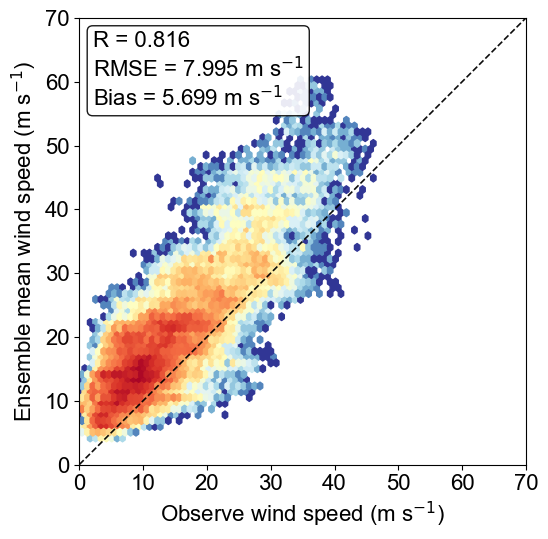

ragasa 48h mean_wspd: saved meanwspd_obs_vs_multi_ai_hexbin_ragasa_48h_20250923-10_to_20250924-10.tif with 43,092 paired station-time samples.


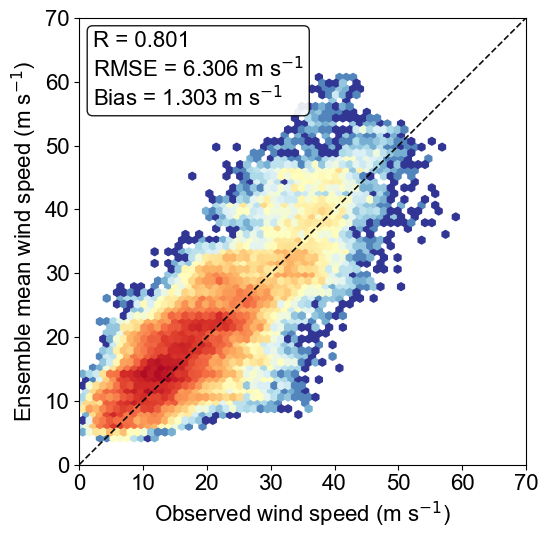

ragasa 48h max_wspd: saved maxwspd_obs_vs_multi_ai_hexbin_ragasa_48h_20250923-10_to_20250924-10.tif with 43,170 paired station-time samples.


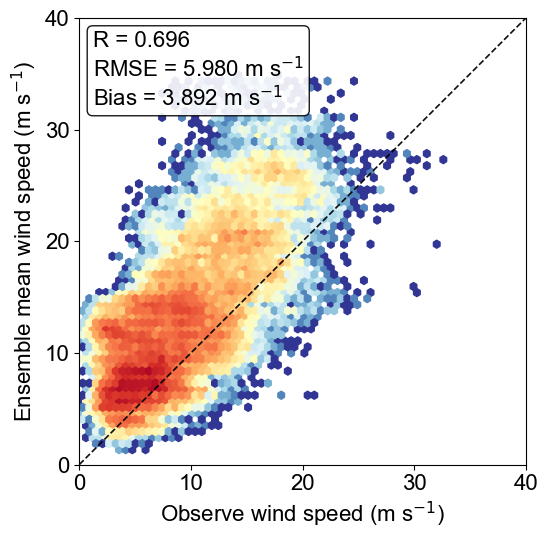

yagi 24h mean_wspd: saved meanwspd_obs_vs_multi_ai_hexbin_yagi_24h_20240905-00_to_20240906-00.tif with 44,627 paired station-time samples.


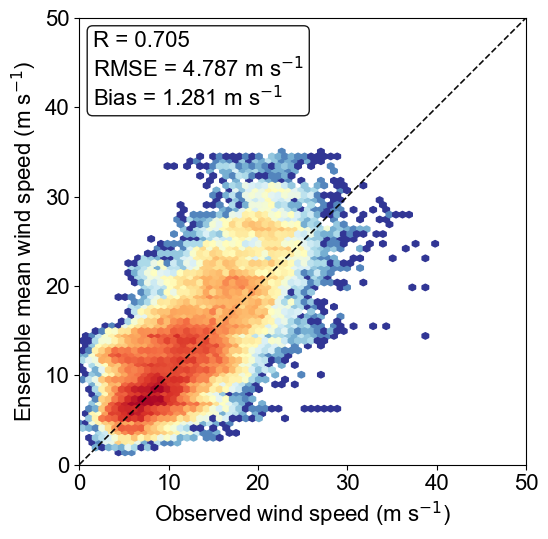

yagi 24h max_wspd: saved maxwspd_obs_vs_multi_ai_hexbin_yagi_24h_20240905-00_to_20240906-00.tif with 44,627 paired station-time samples.


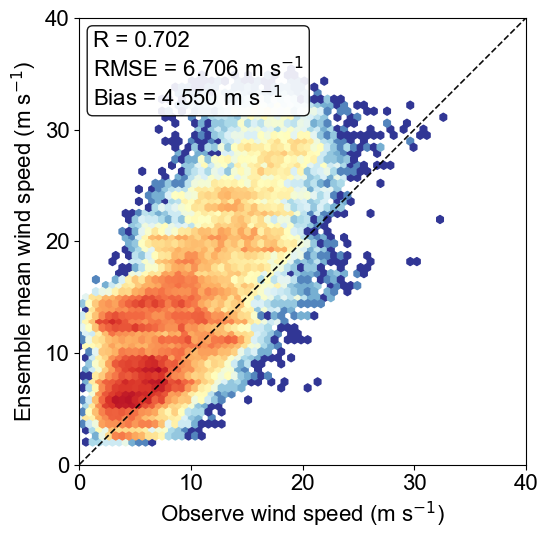

yagi 48h mean_wspd: saved meanwspd_obs_vs_multi_ai_hexbin_yagi_48h_20240905-00_to_20240906-00.tif with 44,627 paired station-time samples.


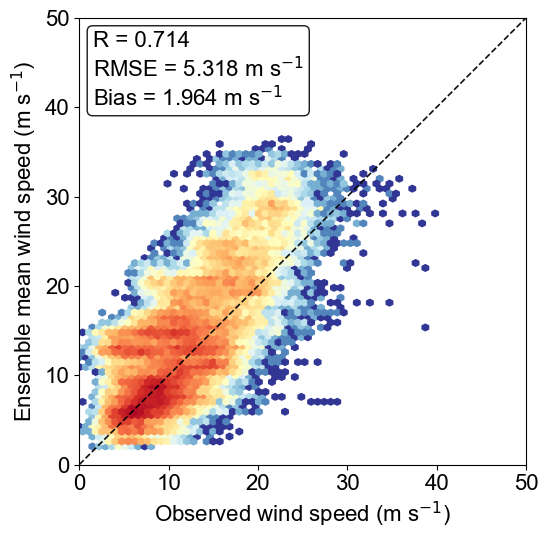

yagi 48h max_wspd: saved maxwspd_obs_vs_multi_ai_hexbin_yagi_48h_20240905-00_to_20240906-00.tif with 44,627 paired station-time samples.


In [2]:
from __future__ import annotations

try:
    START_DIR = Path(__file__).resolve().parent
except NameError:
    START_DIR = Path.cwd()

ROOT_DIR = START_DIR / "Fig4" if (START_DIR / "Fig4").is_dir() else START_DIR
OUTPUT_DIR = ROOT_DIR / "output"

AI_MODELS = ("pangu", "graphcast", "fengwu", "fuxi", "aurora")
LEAD_HOURS_VALUES = (24, 48)
VARIABLES = ("mean_wspd", "max_wspd")

FIGSIZE = (6.2, 5.8)
GRIDSIZE = 55
STATS_FONTSIZE = 16

HEXBIN_CMAP = "RdYlBu_r"

COLORBAR_LABEL = "Counts"

TICK_INTERVAL = 10


def configure_matplotlib() -> None:
    plt.rcParams.update(
        {
            "font.family": "Arial",
            "font.size": 16,
            "axes.labelsize": 16,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
        }
    )


configure_matplotlib()


@dataclass(frozen=True)
class CaseConfig:
    name: str
    layout: str
    data_dir: Path
    window_start_utc: datetime
    window_end_utc: datetime


CASES = (
    CaseConfig(
        name="ragasa",
        layout="flattened",
        data_dir=ROOT_DIR / "input" / "ragasa" / "obs_sim",
        window_start_utc=datetime(2025, 9, 23, 10, 0, tzinfo=timezone.utc),
        window_end_utc=datetime(2025, 9, 24, 10, 0, tzinfo=timezone.utc),
    ),
    CaseConfig(
        name="yagi",
        layout="wide_per_model",
        data_dir=ROOT_DIR / "input" / "yagi",
        window_start_utc=datetime(2024, 9, 5, 0, 0, tzinfo=timezone.utc),
        window_end_utc=datetime(2024, 9, 6, 0, 0, tzinfo=timezone.utc),
    ),
)


@dataclass(frozen=True)
class ForecastFiles:
    case: CaseConfig
    lead_hours: int
    variable: str
    obs_path: Path
    sim_paths: tuple[Path, ...]
    output_path: Path


def build_file_config(case: CaseConfig, lead_hours: int, variable: str) -> ForecastFiles:
    window_text = (
        f"{case.window_start_utc:%Y%m%d-%H}_to_{case.window_end_utc:%Y%m%d-%H}"
    )

    output_prefix = {
        "mean_wspd": "meanwspd",
        "max_wspd": "maxwspd",
    }.get(variable, variable.replace("_", ""))

    case_tag = f"_{case.name}"
    filename = (
        f"{output_prefix}_obs_vs_multi_ai_hexbin{case_tag}_{lead_hours}h_"
        f"{window_text}.tif"
    )

    if case.layout == "flattened":
        obs_path = (
            case.data_dir
            / "results_obs_newT_flattened"
            / f"{variable}_obs_{lead_hours}h_flattened.csv"
        )
        sim_paths = (
            case.data_dir
            / "results_sim_newT_flattened"
            / f"{variable}_sim_{lead_hours}h_flattened.csv",
        )
    elif case.layout == "wide_per_model":
        obs_path = case.data_dir / "results_obs" / f"{variable}_obs.csv"
        sim_paths = tuple(
            case.data_dir
            / "results_sim"
            / f"{model}_{variable}_sim_{lead_hours}h.csv"
            for model in AI_MODELS
        )
    else:
        raise ValueError(f"Unsupported input layout for {case.name}: {case.layout}")

    return ForecastFiles(
        case=case,
        lead_hours=lead_hours,
        variable=variable,
        obs_path=obs_path,
        sim_paths=sim_paths,
        output_path=OUTPUT_DIR / filename,
    )


def read_flattened_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing input file: {path}")
    df = pd.read_csv(path)
    if "timestamp_utc" not in df.columns:
        raise ValueError(f"`timestamp_utc` is missing in {path}")

    df["timestamp_utc"] = pd.to_datetime(
        df["timestamp_utc"], format="%Y%m%d %H%M", utc=True
    )
    df["sample_index"] = df.groupby("timestamp_utc").cumcount()
    return df


def load_flattened_paired_samples(files: ForecastFiles) -> pd.DataFrame:
    obs = read_flattened_csv(files.obs_path)
    if files.variable not in obs.columns:
        raise ValueError(f"`{files.variable}` is missing in {files.obs_path}")
    obs = obs.rename(columns={files.variable: "observed_value"})

    sim_path = files.sim_paths[0]
    sim = read_flattened_csv(sim_path)
    missing_models = [model for model in AI_MODELS if model not in sim.columns]
    if missing_models:
        raise ValueError(
            f"Missing AI model columns in {sim_path}: {', '.join(missing_models)}"
        )

    sim["multi_ai_mean"] = sim[list(AI_MODELS)].mean(axis=1)
    merged = obs.merge(
        sim[["timestamp_utc", "sample_index", "multi_ai_mean"]],
        on=["timestamp_utc", "sample_index"],
        how="inner",
        validate="one_to_one",
    )

    if len(merged) != len(obs) or len(merged) != len(sim):
        raise ValueError(
            "Obs/sim pairing dropped samples after merging on flattened order. "
            f"obs={len(obs):,}, sim={len(sim):,}, merged={len(merged):,}."
        )

    filtered = merged.loc[
        (merged["timestamp_utc"] >= files.case.window_start_utc)
        & (merged["timestamp_utc"] <= files.case.window_end_utc),
        ["timestamp_utc", "observed_value", "multi_ai_mean"],
    ].dropna()

    if filtered.empty:
        available_start = merged["timestamp_utc"].min()
        available_end = merged["timestamp_utc"].max()
        raise ValueError(
            "No paired samples found in the requested UTC window "
            f"{files.case.window_start_utc:%Y-%m-%d %H:%M} to "
            f"{files.case.window_end_utc:%Y-%m-%d %H:%M}. "
            f"Available UTC range is {available_start:%Y-%m-%d %H:%M} "
            f"to {available_end:%Y-%m-%d %H:%M}."
        )

    return filtered


def read_wide_csv(path: Path) -> tuple[pd.DataFrame, list[str]]:
    if not path.exists():
        raise FileNotFoundError(f"Missing input file: {path}")

    df = pd.read_csv(path)
    if "timestamp_utc" not in df.columns:
        raise ValueError(f"`timestamp_utc` is missing in {path}")

    stations = [column for column in df.columns if column != "timestamp_utc"]
    if not stations:
        raise ValueError(f"No station columns found in {path}")
    if len(stations) != len(set(stations)):
        raise ValueError(f"Duplicate station columns found in {path}")

    parsed = pd.to_datetime(
        df["timestamp_utc"], format="%Y%m%d %H%M", utc=True, errors="coerce"
    )
    if parsed.isna().any():
        raise ValueError(f"Invalid `timestamp_utc` values found in {path}")
    if parsed.duplicated().any():
        raise ValueError(f"Duplicate timestamps found in {path}")

    df["timestamp_utc"] = parsed
    df[stations] = df[stations].apply(pd.to_numeric, errors="coerce")
    return df, stations


def subset_wide_to_window(df: pd.DataFrame, files: ForecastFiles, path: Path) -> pd.DataFrame:
    subset = df.loc[
        (df["timestamp_utc"] >= files.case.window_start_utc)
        & (df["timestamp_utc"] <= files.case.window_end_utc)
    ].copy()
    if subset.empty:
        raise ValueError(
            f"No rows in the requested {files.case.name} UTC window for {path}"
        )

    expected_timestamps = int(
        (files.case.window_end_utc - files.case.window_start_utc).total_seconds() / 60
    ) + 1
    if len(subset) != expected_timestamps:
        raise ValueError(
            f"Expected {expected_timestamps:,} one-minute timestamps in {path}, "
            f"found {len(subset):,}."
        )
    return subset


def wide_to_long(df: pd.DataFrame, stations: list[str], value_name: str) -> pd.DataFrame:
    return df.melt(
        id_vars="timestamp_utc",
        value_vars=stations,
        var_name="station",
        value_name=value_name,
    )


def load_wide_paired_samples(files: ForecastFiles) -> pd.DataFrame:
    obs_raw, stations = read_wide_csv(files.obs_path)
    obs = wide_to_long(
        subset_wide_to_window(obs_raw, files, files.obs_path),
        stations,
        "observed_value",
    ).set_index(["timestamp_utc", "station"])

    model_frames = []
    for model, path in zip(AI_MODELS, files.sim_paths):
        sim_raw, sim_stations = read_wide_csv(path)
        if sim_stations != stations:
            missing = sorted(set(stations) - set(sim_stations))
            extra = sorted(set(sim_stations) - set(stations))
            raise ValueError(
                f"Station columns do not match observations in {path}; "
                f"missing={missing}, extra={extra}."
            )
        model_frames.append(
            wide_to_long(
                subset_wide_to_window(sim_raw, files, path), stations, model
            ).set_index(["timestamp_utc", "station"])
        )

    merged = pd.concat([obs, *model_frames], axis=1, join="inner")
    if merged.empty:
        raise ValueError(f"No common station-time samples found for {files.case.name}")
    expected_samples = len(obs)
    if len(merged) != expected_samples:
        raise ValueError(
            f"Station-time alignment dropped samples for {files.case.name}: "
            f"expected={expected_samples:,}, merged={len(merged):,}."
        )

    merged["multi_ai_mean"] = merged[list(AI_MODELS)].mean(axis=1)
    return (
        merged[["observed_value", "multi_ai_mean"]]
        .dropna()
        .reset_index()
    )


def load_paired_samples(files: ForecastFiles) -> pd.DataFrame:
    if files.case.layout == "flattened":
        return load_flattened_paired_samples(files)
    if files.case.layout == "wide_per_model":
        return load_wide_paired_samples(files)
    raise ValueError(f"Unsupported input layout for {files.case.name}: {files.case.layout}")


def compute_stats(observed: np.ndarray, predicted: np.ndarray) -> tuple[float, float, float]:
    correlation = float(np.corrcoef(observed, predicted)[0, 1])
    rmse = float(np.sqrt(np.mean((predicted - observed) ** 2)))
    bias = float(np.mean(predicted - observed))
    return correlation, rmse, bias


def log10_ticks_from_range(vmin: float, vmax: float) -> list[float]:
    if not (math.isfinite(vmin) and math.isfinite(vmax)) or vmin <= 0 or vmax <= 0:
        return [1.0]
    if vmax < vmin:
        vmin, vmax = vmax, vmin

    pmin = int(math.floor(math.log10(vmin)))
    pmax = int(math.ceil(math.log10(vmax)))
    ticks = [float(10**p) for p in range(pmin, pmax + 1)]
    return [t for t in ticks if vmin <= t <= vmax]


def load_all_samples() -> list[tuple[ForecastFiles, pd.DataFrame]]:
    sample_sets = []
    for case in CASES:
        for lead_hours in LEAD_HOURS_VALUES:
            for variable in VARIABLES:
                files = build_file_config(case, lead_hours, variable)
                sample_sets.append((files, load_paired_samples(files)))
    return sample_sets


def compute_global_hexbin_count_range(
    sample_sets: list[tuple[ForecastFiles, pd.DataFrame]],
) -> tuple[float, float]:
    global_vmin = 1.0
    global_vmax = 1.0

    for _, samples in sample_sets:
        observed = samples["observed_value"].to_numpy()
        predicted = samples["multi_ai_mean"].to_numpy()

        fig, ax = plt.subplots(figsize=(1, 1))
        hb = ax.hexbin(
            observed,
            predicted,
            gridsize=GRIDSIZE,
            mincnt=1,
            cmap=HEXBIN_CMAP,
            norm=LogNorm(),
        )
        counts = np.asarray(hb.get_array())
        if counts.size:
            global_vmax = max(global_vmax, float(np.nanmax(counts)))
        plt.close(fig)

    return global_vmin, global_vmax


def labels_for_variable(variable: str) -> tuple[str, str]:
    if variable == "mean_wspd":
        x_label = "Observe wind speed (m s$^{-1}$)"
        y_label = "Ensemble mean wind speed (m s$^{-1}$)"
        return x_label, y_label

    if variable == "max_wspd":
        x_label = "Observed wind speed (m s$^{-1}$)"
        y_label = "Ensemble mean wind speed (m s$^{-1}$)"
        return x_label, y_label

    x_label = "Observed wind speed (m s$^{-1}$)"
    y_label = "Ensemble mean wind speed (m s$^{-1}$)"
    return x_label, y_label


def plot_hexbin(
    samples: pd.DataFrame,
    files: ForecastFiles,
    *,
    norm=None,
    show: bool = True,
) -> None:
    observed = samples["observed_value"].to_numpy()
    predicted = samples["multi_ai_mean"].to_numpy()
    correlation, rmse, bias = compute_stats(observed, predicted)

    axis_max = float(np.nanmax([observed.max(), predicted.max()]))
    axis_max = max(1.0, axis_max)
    axis_max = int(math.ceil(axis_max / TICK_INTERVAL) * TICK_INTERVAL)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.hexbin(
        observed,
        predicted,
        gridsize=GRIDSIZE,
        mincnt=1,
        cmap=HEXBIN_CMAP,
        norm=norm if norm is not None else LogNorm(),
    )

    ax.plot(
        [0, axis_max],
        [0, axis_max],
        linestyle="--",
        linewidth=1.2,
        color="black",
        alpha=0.95,
    )

    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.set_aspect("equal", adjustable="box")
    ticks = np.arange(0, axis_max + TICK_INTERVAL, TICK_INTERVAL)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    x_label, y_label = labels_for_variable(files.variable)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    stats_text = "\n".join(
        [
            f"R = {correlation:.3f}",
            f"RMSE = {rmse:.3f} m s$^{{-1}}$",
            f"Bias = {bias:.3f} m s$^{{-1}}$",
        ]
    )
    ax.text(
        0.03,
        0.97,
        stats_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=STATS_FONTSIZE,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.9},
    )

    files.output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(files.output_path, dpi=600, bbox_inches="tight")

    if show:
        plt.show()

    plt.close(fig)


def main(*, show: bool = True) -> LogNorm:
    for case in CASES:
        print(
            f"{case.name.title()} UTC window: "
            f"{case.window_start_utc:%Y-%m-%d %H:%M} to "
            f"{case.window_end_utc:%Y-%m-%d %H:%M} (inclusive)."
        )

    sample_sets = load_all_samples()
    vmin, vmax = compute_global_hexbin_count_range(sample_sets)
    shared_norm = LogNorm(vmin=vmin, vmax=vmax)
    print(f"Shared hexbin LogNorm range for color scale: vmin={vmin:g}, vmax={vmax:g}")

    for files, samples in sample_sets:
        plot_hexbin(samples, files, norm=shared_norm, show=show)
        print(
            f"{files.case.name} {files.lead_hours}h {files.variable}: saved "
            f"{files.output_path.name} with {len(samples):,} paired "
            "station-time samples."
        )

    return shared_norm


HEXBIN_NORM = main(show=True)


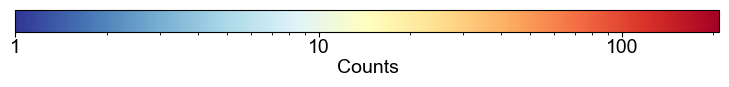

Saved standalone colorbar: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig4\output\hexbin_counts_colorbar_horizontal.tif


WindowsPath('E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig4/output/hexbin_counts_colorbar_horizontal.tif')

In [3]:
from matplotlib.cm import ScalarMappable


def draw_standalone_horizontal_colorbar(*, show: bool = True) -> Path:
    """Draw a shared horizontal colorbar for the hexbin plots (long and thin)."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out_path = OUTPUT_DIR / "hexbin_counts_colorbar_horizontal.tif"

    try:
        norm = HEXBIN_NORM
    except NameError:
        # Fallback if this cell is run before the plotting cell.
        vmin, vmax = compute_global_hexbin_count_range(load_all_samples())
        norm = LogNorm(vmin=vmin, vmax=vmax)

    sm = ScalarMappable(norm=norm, cmap=HEXBIN_CMAP)
    sm.set_array([])

    # Long + thin canvas; create a dedicated axes for the bar.
    fig = plt.figure(figsize=(8, 0.8))
    cax = fig.add_axes([0.06, 0.45, 0.88, 0.28])

    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(COLORBAR_LABEL, fontsize=14, labelpad=2)
    cbar.ax.tick_params(labelsize=14, pad=1)

    ticks = log10_ticks_from_range(float(norm.vmin), float(norm.vmax))
    cbar.set_ticks(ticks)
    cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
    cbar.ax.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    cbar.ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    fig.savefig(out_path, dpi=600, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    print(f"Saved standalone colorbar: {out_path}")
    return out_path


draw_standalone_horizontal_colorbar(show=True)